This notebook contains implementations for algorithms that perform combinatorical generation on combinations.

In [1]:
import numpy as np
from sympy import *
import scipy
import math
import decimal
import pandas as pd
import seaborn as sns

In [2]:
test_list = list(subsets([1,2,3,4], 2))

In [3]:
test_list

[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

In [4]:
test_list

[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

In [5]:
cur_rank = 10


In [6]:
n = 5
k = 2

for rank in range(int(scipy.special.binom(n, k))):
    res = []
    i = k
    cur_rank = rank
    while i >= 1:
        for p in range(i-1,n+1):
            cur_binom = scipy.special.binom(p, i)
            if cur_binom > cur_rank:
                cur_rank = cur_rank - scipy.special.binom(p-1, i)
                res.append(p)
                i -= 1
                break

    print(f"{rank} : {res}")

0 : [2, 1]
1 : [3, 1]
2 : [3, 2]
3 : [4, 1]
4 : [4, 2]
5 : [4, 3]
6 : [5, 1]
7 : [5, 2]
8 : [5, 3]
9 : [5, 4]


In [7]:
def old_get_combination(n, k, rank):
    res = np.empty(k, dtype=int)
    res_counter = 0
    i = k
    cur_rank = rank
    while i >= 1:
        if cur_rank == 0:
            p_start = i-1
        else:
            p_start = int(np.ceil(np.log2(cur_rank)))
        for p in range(p_start,n+1):
            cur_binom = scipy.special.binom(p, i)
            
            if cur_binom > cur_rank:
                cur_rank = cur_rank - scipy.special.binom(p-1, i)
                res[res_counter] = p
                i -= 1
                res_counter += 1
                break
    return res

In [8]:
def get_p(n, k, r):
    if r <= 0:
        return k
    # Calculate bounds
    upper_n = np.floor((r*(k**k))**(1/k))

    # If the upper bound is less than k, then p must be k+1
    if upper_n < k:
        return k+1
    
    #if n < upper_n:
    #    upper_n = n
    
    lower_n = np.ceil((r*(math.factorial(k)))**(1/k))
    #if k > lower_n:
    #    lower_n = k

    if upper_n == lower_n:
        if scipy.special.binom(upper_n, k) > r:
            return upper_n
        else:
            return upper_n + 1
    # Binary search for the correct p value
    counter = 0
    while True:
        if counter > 1000:
            print("Debug case")
            
        cur_p = lower_n + int((upper_n - lower_n)/2)
        cur_binom = scipy.special.binom(cur_p, k)
        if cur_binom > r:
            # The binomial coefficient is greater than the rank
            # find binom(p-1, k)
            lower_p_binom = cur_binom*(cur_p-k)/cur_p
            if lower_p_binom <= r:
                return cur_p
            else:
                upper_n = cur_p
        if cur_binom <= r:
            # The p value is too low
            lower_n = cur_p + 1
        
        counter += 1


In [9]:
def get_combination(n, k, rank):
    res = np.empty(k, dtype=int)
    res_counter = 0
    i = k
    cur_rank = rank
    while i >= 1:
        p = get_p(n, i, cur_rank)
        cur_rank = cur_rank - scipy.special.binom(p-1, i)
        res[res_counter] = p
        i -= 1
        res_counter += 1

    return res

In [10]:
n = 4
k = 2
r_range = int(scipy.special.binom(4, 2))
for r in range(r_range):
    print(get_combination(n, k, r))
    print(old_get_combination(n, k, r))

[2 1]
[2 1]
[3 1]
[3 1]
[3 2]
[3 2]
[4 1]
[4 1]
[4 2]
[4 2]
[4 3]
[4 3]


In [11]:
scipy.special.binom(7, 6)

7.0

In [12]:
get_combination(16, 6, 1)


array([7, 5, 4, 3, 2, 1])

In [13]:
int(decimal.Decimal(math.factorial(25))/decimal.Decimal((math.factorial(5))**(5)))

623360743125120

In [22]:
m=j=3
str_list = []
print(int(decimal.Decimal(math.factorial(m*j))/decimal.Decimal((math.factorial(m))**(j))))
permutation_dataset = {"Rank" : [], "Permutation" : [], "Permutation_val" : []}
for rank in range(int(decimal.Decimal(math.factorial(m*j))/decimal.Decimal((math.factorial(m))**(j)))):
    if rank % 10000 == 0:
        print(f"Rank reached: {rank}")
        if rank > 100000:
            break

    perm_number = rank
    final_result = np.ones(m*j, dtype=int)*-1
    for k in range(j):
        # For each job
        cur_max = m*(j-k-1)
        if cur_max == 0:
            # Add the last job number in the remaining spaces
            final_result[final_result == -1] = k
        else:
            # Number of possible permutations is calculated by
            n_permutations = int(decimal.Decimal(math.factorial(cur_max))/decimal.Decimal((math.factorial(m))**(j-k-1)))
            n_combinations = math.factorial(m*(j-k-1))//(math.factorial(m)*math.factorial((m*(j-k-1))-m))
            # Find the number of times the number of permutations with j-1 goes in the permutations number
            cur_period_number = perm_number % n_combinations
            # Find the new permutation number by finding the rest
            perm_number = int(perm_number) % n_permutations

            # Place the m elements of value j in the array.
            # This is done by finding the k-combination of an n-size integer set.
            temp_comb = get_combination(m*(j-k), m, cur_period_number)-1
            # Add the job numbers into the result array according to the combination created of index values
            temp_final_result = final_result[final_result == -1]
            temp_final_result[temp_comb] = k
            #for i in temp_comb:
            #    temp_final_result[i] = k

            final_result[final_result == -1] = temp_final_result

    print(f"{rank} : {final_result}")
    permutation_dataset["Rank"].append(rank)
    permutation_dataset["Permutation"].append(final_result)
    permutation_dataset["Permutation_val"].append(int("".join(final_result.astype(str)), j))
    str_list.append("".join(list(final_result.astype(str))))

1680
Rank reached: 0
0 : [0 0 0 1 1 1 2 2 2]
1 : [0 0 1 0 1 1 2 2 2]
2 : [0 1 0 0 1 1 2 2 2]
3 : [1 0 0 0 1 1 2 2 2]
4 : [0 0 1 1 0 1 2 2 2]
5 : [0 1 0 1 0 1 2 2 2]
6 : [1 0 0 1 0 1 2 2 2]
7 : [0 1 1 0 0 1 2 2 2]
8 : [1 0 1 0 0 1 2 2 2]
9 : [1 1 0 0 0 1 2 2 2]
10 : [0 0 1 1 1 0 2 2 2]
11 : [0 1 0 1 1 0 2 2 2]
12 : [1 0 0 1 1 0 2 2 2]
13 : [0 1 1 0 1 0 2 2 2]
14 : [1 0 1 0 1 0 2 2 2]
15 : [1 1 0 0 1 0 2 2 2]
16 : [0 1 1 1 0 0 2 2 2]
17 : [1 0 1 1 0 0 2 2 2]
18 : [1 1 0 1 0 0 2 2 2]
19 : [1 1 1 0 0 0 2 2 2]
20 : [0 0 0 1 1 1 2 2 2]
21 : [0 0 1 0 1 1 2 2 2]
22 : [0 1 0 0 1 1 2 2 2]
23 : [1 0 0 0 1 1 2 2 2]
24 : [0 0 1 1 0 1 2 2 2]
25 : [0 1 0 1 0 1 2 2 2]
26 : [1 0 0 1 0 1 2 2 2]
27 : [0 1 1 0 0 1 2 2 2]
28 : [1 0 1 0 0 1 2 2 2]
29 : [1 1 0 0 0 1 2 2 2]
30 : [0 0 1 1 1 0 2 2 2]
31 : [0 1 0 1 1 0 2 2 2]
32 : [1 0 0 1 1 0 2 2 2]
33 : [0 1 1 0 1 0 2 2 2]
34 : [1 0 1 0 1 0 2 2 2]
35 : [1 1 0 0 1 0 2 2 2]
36 : [0 1 1 1 0 0 2 2 2]
37 : [1 0 1 1 0 0 2 2 2]
38 : [1 1 0 1 0 0 2 2 2]
39 : [1 1 1 0 

In [23]:
cur_dataset = pd.DataFrame(permutation_dataset)
cur_dataset.head()

,Rank,Permutation,Permutation_val
0,0,"[0, 0, 0, 1, 1, 1, 2, 2, 2]",377
1,1,"[0, 0, 1, 0, 1, 1, 2, 2, 2]",863
2,2,"[0, 1, 0, 0, 1, 1, 2, 2, 2]",2321
3,3,"[1, 0, 0, 0, 1, 1, 2, 2, 2]",6695
4,4,"[0, 0, 1, 1, 0, 1, 2, 2, 2]",1025


<Axes: xlabel='Rank', ylabel='Permutation_val'>

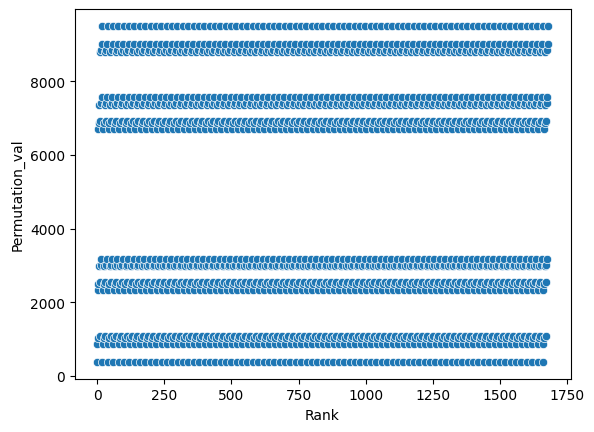

In [24]:
sns.scatterplot(data=cur_dataset, x="Rank", y="Permutation_val")

In [18]:
int("".join(final_result.astype(str)), 3)

19305

In [19]:
len(set(str_list))

1680

In [15]:
def new_binom(n, k):
    total = 1
    for i in range(k):
        total *= (n-i)/(k-i)

    return total

In [20]:
for n in range(3, 8):
    for k in range(2, 4):
        scipy_binom = scipy.special.binom(n, k)
        alt_binom = new_binom(n, k)
        if scipy_binom != alt_binom:
            print(n, k)

        

In [21]:
import time

In [28]:
start_time = time.time()
for n in range(3, 1000):
    for k in range(2, 500):
        scipy_binom = scipy.special.binom(n, k)
        #alt_binom = new_binom(n, k)
        
print(time.time() - start_time)

2.2911832332611084


In [29]:
start_time = time.time()
for n in range(3, 1000):
    for k in range(2, 500):
        scipy_binom = new_binom(n, k)
        #alt_binom = new_binom(n, k)
        
print(time.time() - start_time)

27.39368963241577


### Improving the unranking of combinations

The main source of time usage in the algorihtm is the part where p is minimized with the constraint binom(p, i) > r.

A rough upper estimate of the binomialcoefficient is given by:
binom(n,k) <= 2**n

In [5]:
# example problem
n = 10
k = 4

print(scipy.special.binom(n, k))
r = np.ceil(scipy.special.binom(n, k) / 2)

210.0


In [6]:
print(r)

105.0


In [8]:
calc_n = np.ceil(np.log(r)/np.log(2))
print("calc_n: " + str(calc_n))
print(scipy.special.binom(calc_n+1, k))
print(scipy.special.binom(calc_n, k))
print(scipy.special.binom(calc_n-1, k))

calc_n: 7.0
70.0
35.0
15.0


In [15]:
2**(7)

128

In [16]:
print(scipy.special.binom(7, k))

35.0


In [13]:
print(scipy.special.binom(calc_n+2, k))

126.0


A way to further improve the unranking is to introduce binary search for the correct p value and use the bound for binmial coefficients:
$$ \frac{n^k}{k^k} \leq \binom{n}{k} \leq \frac{n^k}{k!}$$

In [135]:
n = 4
k = 2
r = 3
scipy.special.binom(n, k)

6.0

In [136]:
upper_n = np.floor((r*(k**k))**(1/k))
lower_n = np.ceil(np.log(r)/np.log(2))

In [137]:
lower_n

2.0

In [138]:
upper_n

3.0

In [72]:
np.ceil((r*(math.factorial(k)))**(1/k))

17.0

In [74]:
scipy.special.binom(upper_n, k)

169911.0

In [75]:
scipy.special.binom(10,5)

252.0

In [76]:
scipy.special.binom(10-1,5)

126.0

In [80]:
k = 3
for n in range(5, 15):
    normal = scipy.special.binom(n,k)
    # n-1
    lower = scipy.special.binom(n,k)*(n-k)/n
    actual_lower = scipy.special.binom(n-1,k)
    if not lower == actual_lower:
        print("Not OK")